In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/vaikh/Downloads/funnel_project.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11875 entries, 0 to 11874
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   event_date      11875 non-null  object 
 1   event_ts        11875 non-null  object 
 2   user_pseudo_id  11875 non-null  float64
 3   ga_session_id   11875 non-null  int64  
 4   event_name      11875 non-null  object 
 5   page_location   11875 non-null  object 
 6   page_referrer   3422 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 649.5+ KB


In [4]:
df.shape

(11875, 7)

In [5]:
df.isnull().sum()

event_date           0
event_ts             0
user_pseudo_id       0
ga_session_id        0
event_name           0
page_location        0
page_referrer     8453
dtype: int64

In [6]:
## converts the timestamp into datetime
df['event_ts'] = pd.to_datetime(df['event_ts'])

In [7]:
## sorting or grouping the entire dataset by event time, session id, psuedo id

df = df.sort_values(by=['user_pseudo_id', 'ga_session_id', 'event_ts'])

funnel_steps = [
    'view_item',
    'add_to_cart',
    'begin_checkout',
    'purchase'
]

funnel_df = df[df['event_name'].isin(funnel_steps)]

In [8]:
## this code creates a new df of session funnel where it takes the funnel steps into account and groups by session id and event name

session_funnel = (
    funnel_df
    .groupby('ga_session_id')['event_name']
    .apply(set)
    .reset_index()
)


In [9]:
## I created binary columns to understand which session reached atleast 1 step

for step in funnel_steps:
    session_funnel[step] = session_funnel['event_name'].apply(
        lambda x: 1 if step in x else 0
    )

In [10]:
session_funnel.head()


,ga_session_id,event_name,view_item,add_to_cart,begin_checkout,purchase
0,303399,{view_item},1,0,0,0
1,10897833,{view_item},1,0,0,0
2,20502564,{view_item},1,0,0,0
3,21525767,"{view_item, add_to_cart}",1,1,0,0
4,22842583,{view_item},1,0,0,0


In [11]:
## counting how many sessions reached each step

funnel_steps = ['view_item',
    'add_to_cart',
    'begin_checkout',
    'purchase'
]


In [12]:
counts = session_funnel[funnel_steps].sum()
counts

view_item         571
add_to_cart       104
begin_checkout     56
purchase           18
dtype: int64

In [14]:
conversion_rates = counts / counts.iloc[0]
conversion_rates

view_item         1.000000
add_to_cart       0.182137
begin_checkout    0.098074
purchase          0.031524
dtype: float64

In [16]:
step_conversion = counts / counts.shift(1)
step_conversion

view_item              NaN
add_to_cart       0.182137
begin_checkout    0.538462
purchase          0.321429
dtype: float64

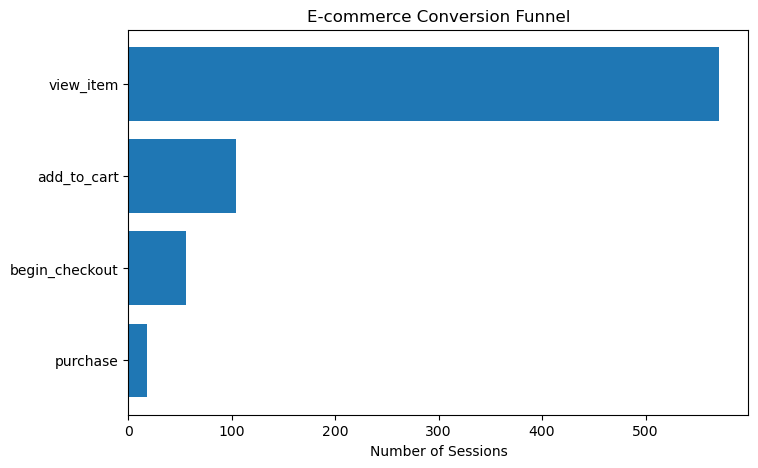

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(counts.index, counts.values)
plt.title("E-commerce Conversion Funnel")
plt.xlabel("Number of Sessions")
plt.gca().invert_yaxis()
plt.show()

In [18]:
## 1. Drop-off analysis
dropoff_rates = (1 - step_conversion).dropna() * 100

print("=== FUNNEL SUMMARY ===")
print(f"Total sessions that viewed an item: {counts['view_item']}")
print(f"Sessions that completed a purchase: {counts['purchase']}")
print(f"Overall conversion rate: {conversion_rates['purchase']*100:.1f}%\n")

print("=== STEP-BY-STEP DROP-OFF ===")
steps = [
    ("View → Add to Cart",     "add_to_cart"),
    ("Add to Cart → Checkout", "begin_checkout"),
    ("Checkout → Purchase",    "purchase"),
]
for label, step in steps:
    dropped = dropoff_rates.get(step, 0)
    print(f"{label}: {dropped:.1f}% dropped off")


=== FUNNEL SUMMARY ===
Total sessions that viewed an item: 571
Sessions that completed a purchase: 18
Overall conversion rate: 3.2%

=== STEP-BY-STEP DROP-OFF ===
View → Add to Cart: 81.8% dropped off
Add to Cart → Checkout: 46.2% dropped off
Checkout → Purchase: 67.9% dropped off


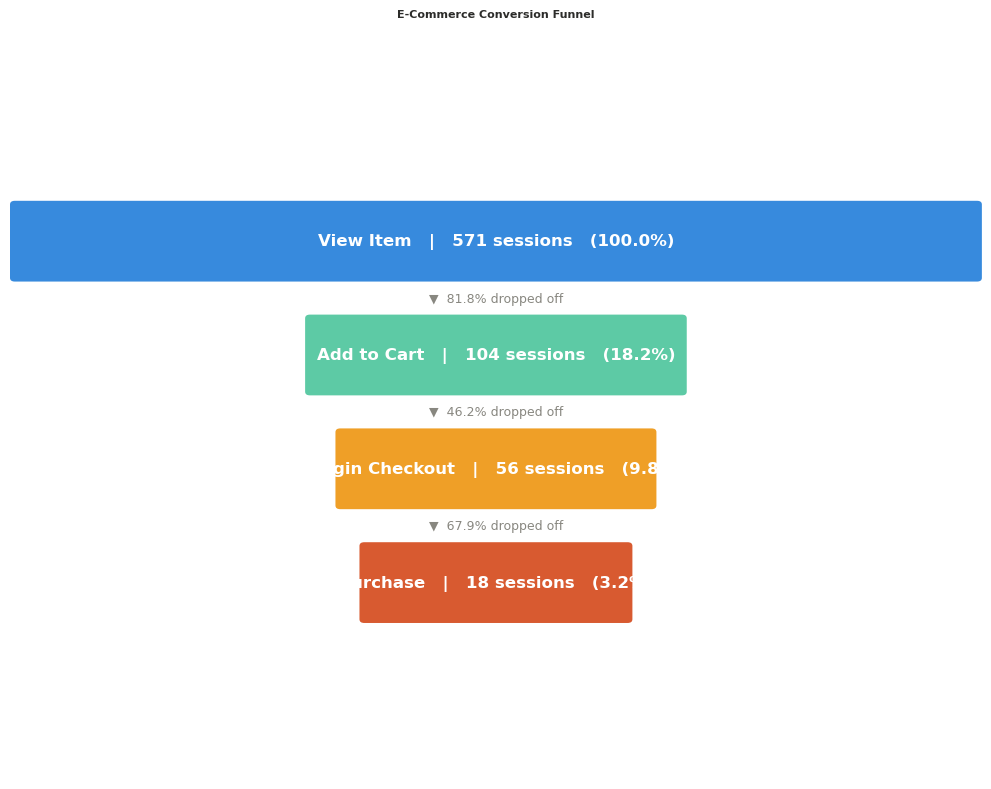

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

labels = ['View Item', 'Add to Cart', 'Begin Checkout', 'Purchase']
values = [571, 104, 56, 18]
colors = ['#378ADD', '#5DCAA5', '#EF9F27', '#D85A30']
dropoffs = ['81.8% dropped off', '46.2% dropped off', '67.9% dropped off']

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

n = len(labels)
bar_height = 0.10
gap = 0.055
total_block = n * bar_height + (n - 1) * gap
start_y = (1 - total_block) / 2 + total_block  # top-down

for i, (label, val, color) in enumerate(zip(labels, values, colors)):
    width = 0.25 + 0.75 * (val / values[0])   # min 25%, max 100%
    x0 = (1 - width) / 2
    y0 = start_y - i * (bar_height + gap) - bar_height

    rect = mpatches.FancyBboxPatch(
        (x0, y0), width, bar_height,
        boxstyle="round,pad=0.005",
        linewidth=0, facecolor=color,
        transform=ax.transData, clip_on=False
    )
    ax.add_patch(rect)

    pct = val / values[0] * 100
    ax.text(0.5, y0 + bar_height / 2,
            f"{label}   |   {val:,} sessions   ({pct:.1f}%)",
            ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            transform=ax.transData)

    if i < n - 1:
        drop_y = y0 - gap / 2
        ax.text(0.5, drop_y,
                f"▼  {dropoffs[i]}",
                ha='center', va='center',
                fontsize=9, color='#888780',
                transform=ax.transData)

ax.set_title("E-Commerce Conversion Funnel",
             fontsize=8, fontweight='bold', color='#2C2C2A', pad=20)

plt.tight_layout()
plt.savefig("funnel_chart.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
## 3. Referrer impact on conversion
referrer_df = df.copy()
referrer_df['has_referrer'] = referrer_df['page_referrer'].notna()

# Tag each session with whether it had a referrer at any point
session_referrer = (
    referrer_df.groupby('ga_session_id')['has_referrer']
    .max()
    .reset_index()
    .rename(columns={'has_referrer': 'referred'})
)

merged = session_funnel.merge(session_referrer, on='ga_session_id')

print("=== CONVERSION BY TRAFFIC SOURCE ===")
for group, label in [(True, 'With referrer'), (False, 'Direct / No referrer')]:
    subset = merged[merged['referred'] == group]
    total = len(subset)
    purchased = subset['purchase'].sum()
    rate = purchased / total * 100 if total > 0 else 0
    print(f"{label}: {purchased}/{total} sessions purchased ({rate:.1f}%)")


=== CONVERSION BY TRAFFIC SOURCE ===
With referrer: 18/292 sessions purchased (6.2%)
Direct / No referrer: 0/281 sessions purchased (0.0%)


In [22]:
## 5. User-level: sessions per user & multi-session purchasers
user_sessions = (
    df.groupby('user_pseudo_id')['ga_session_id']
    .nunique()
    .reset_index()
    .rename(columns={'ga_session_id': 'session_count'})
)

# Join purchase info at session level, then aggregate to user level
session_purchase = session_funnel[['ga_session_id','purchase']]
user_session_map = df[['user_pseudo_id','ga_session_id']].drop_duplicates()

user_data = user_session_map.merge(session_purchase, on='ga_session_id')
user_summary = (
    user_data.groupby('user_pseudo_id')
    .agg(total_sessions=('ga_session_id','nunique'),
         purchased=('purchase','max'))
    .reset_index()
)

single = user_summary[user_summary['total_sessions'] == 1]
multi  = user_summary[user_summary['total_sessions'] > 1]

print("=== USER BEHAVIOUR ===")
print(f"Single-session users: {len(single)} "
      f"({single['purchased'].mean()*100:.1f}% converted)")
print(f"Multi-session users:  {len(multi)} "
      f"({multi['purchased'].mean()*100:.1f}% converted)")


=== USER BEHAVIOUR ===
Single-session users: 525 (2.9% converted)
Multi-session users:  29 (6.9% converted)



## Key Findings & Business Recommendations

| Funnel Step | Sessions | Drop-off |
|---|---|---|
| View Item | 571 | — |
| Add to Cart | 104 | 81.8% |
| Begin Checkout | 56 | 46.2% |
| Purchase | 18 | 67.9% |

**Overall conversion rate: 3.2%** (industry average: 2–4% — we are at the lower end)

### Biggest opportunity: Add to Cart → Checkout (46% drop)
- Investigate cart page UX: is checkout flow too long?
- Consider guest checkout or saved payment options
- A/B test cart abandonment email reminders

### Secondary opportunity: Checkout → Purchase (68% drop)
- Review payment failure rates and error messages
- Ensure trust signals (SSL badge, return policy) are visible
- Simplify the final confirmation step
"""


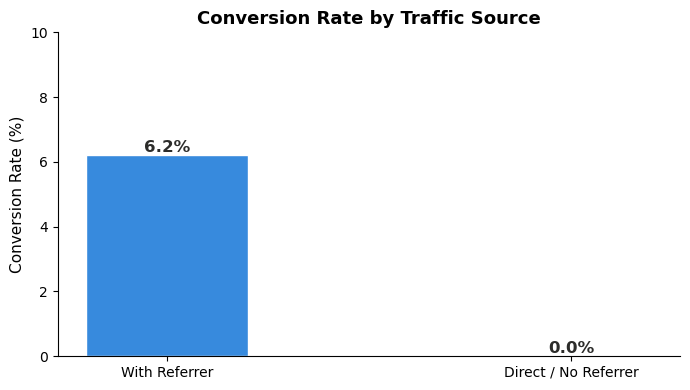

In [30]:
import matplotlib.pyplot as plt

labels = ['With Referrer', 'Direct / No Referrer']
rates = [6.2, 0.0]
colors = ['#378ADD', '#D3D1C7']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, rates, color=colors, width=0.4, edgecolor='white')

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{rate}%", ha='center', fontsize=12, fontweight='bold', color='#2C2C2A')

ax.set_ylabel("Conversion Rate (%)", fontsize=11)
ax.set_title("Conversion Rate by Traffic Source", fontsize=13, fontweight='bold')
ax.set_ylim(0, 10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("referrer_chart.png", dpi=150, bbox_inches='tight')
plt.show()

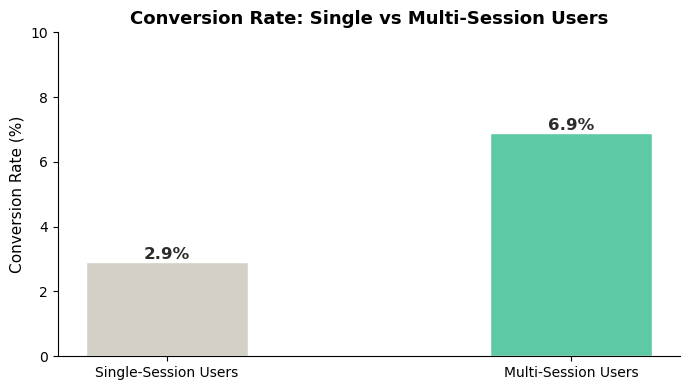

In [31]:
labels = ['Single-Session Users', 'Multi-Session Users']
rates = [2.9, 6.9]
colors = ['#D3D1C7', '#5DCAA5']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, rates, color=colors, width=0.4, edgecolor='white')

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{rate}%", ha='center', fontsize=12, fontweight='bold', color='#2C2C2A')

ax.set_ylabel("Conversion Rate (%)", fontsize=11)
ax.set_title("Conversion Rate: Single vs Multi-Session Users", fontsize=13, fontweight='bold')
ax.set_ylim(0, 10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("user_behaviour_chart.png", dpi=150, bbox_inches='tight')
plt.show()